# Data analysis  
## 1. Environment & paths  

In [1]:
import os
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from IPython.display import Image, display

# Display figures inline in the notebook
%matplotlib inline

# Project root directory
PROJECT_ROOT = r"C:\Users\b1795\Desktop\Laboratory2_SP"

DATA_RAW_DIR = os.path.join(PROJECT_ROOT, "data_raw")
DATA_PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data_processed")
FIGURES_DIR = os.path.join(PROJECT_ROOT, "figures")

os.makedirs(FIGURES_DIR, exist_ok=True)

# Part B outputs
TRAIN_POS_TSV = os.path.join(DATA_PROCESSED_DIR, "training_positive.tsv")
TRAIN_NEG_TSV = os.path.join(DATA_PROCESSED_DIR, "training_negative.tsv")
BENCH_POS_TSV = os.path.join(DATA_PROCESSED_DIR, "benchmark_positive.tsv")
BENCH_NEG_TSV = os.path.join(DATA_PROCESSED_DIR, "benchmark_negative.tsv")

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_PROCESSED_DIR:", DATA_PROCESSED_DIR)
print("FIGURES_DIR:", FIGURES_DIR)

# Global seaborn style
sns.set(style="whitegrid", context="talk")

PROJECT_ROOT: C:\Users\b1795\Desktop\Laboratory2_SP
DATA_PROCESSED_DIR: C:\Users\b1795\Desktop\Laboratory2_SP\data_processed
FIGURES_DIR: C:\Users\b1795\Desktop\Laboratory2_SP\figures


## 2. Load datasets & helpers

In [2]:
def load_tsv(path, label):
    """Load a TSV file and add a set_label column for downstream merging."""
    df = pd.read_csv(path, sep="\t")
    df["set_label"] = label
    print(f"{label}: {path} -> {df.shape[0]} rows, {df.shape[1]} columns")
    return df
df_train_pos = load_tsv(TRAIN_POS_TSV, "train_positive")
df_train_neg = load_tsv(TRAIN_NEG_TSV, "train_negative")
df_bench_pos = load_tsv(BENCH_POS_TSV, "bench_positive")
df_bench_neg = load_tsv(BENCH_NEG_TSV, "bench_negative")
# Select the first existing column from multiple candidate column names
def pick_column(df, candidates, required=True):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f"None of the candidate columns {candidates} found in DataFrame.")
    else:
        return None
print("Training positive columns:", df_train_pos.columns.tolist())
print("Training negative columns:", df_train_neg.columns.tolist())

train_positive: C:\Users\b1795\Desktop\Laboratory2_SP\data_processed\training_positive.tsv -> 2348 rows, 6 columns
train_negative: C:\Users\b1795\Desktop\Laboratory2_SP\data_processed\training_negative.tsv -> 16492 rows, 6 columns
bench_positive: C:\Users\b1795\Desktop\Laboratory2_SP\data_processed\benchmark_positive.tsv -> 587 rows, 6 columns
bench_negative: C:\Users\b1795\Desktop\Laboratory2_SP\data_processed\benchmark_negative.tsv -> 4123 rows, 6 columns
Training positive columns: ['accession', 'organism', 'kingdom', 'length', 'sp_cleavage_site', 'set_label']
Training negative columns: ['accession', 'organism', 'kingdom', 'length', 'tm_helix_start_leq_90', 'set_label']


## 3. Protein length distributions

Length column (pos): length
Length column (neg): length


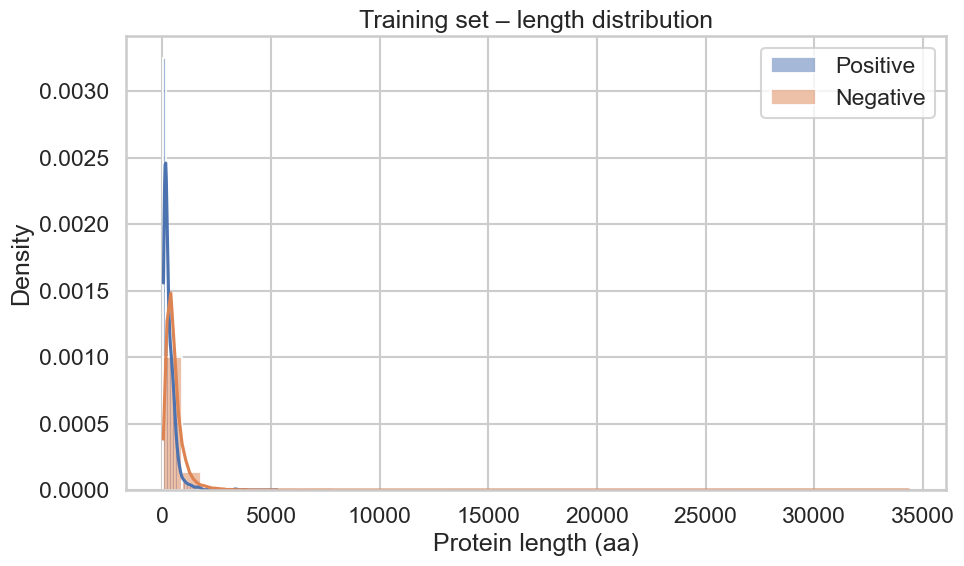

Saved: C:\Users\b1795\Desktop\Laboratory2_SP\figures\training_length_hist_kde.png


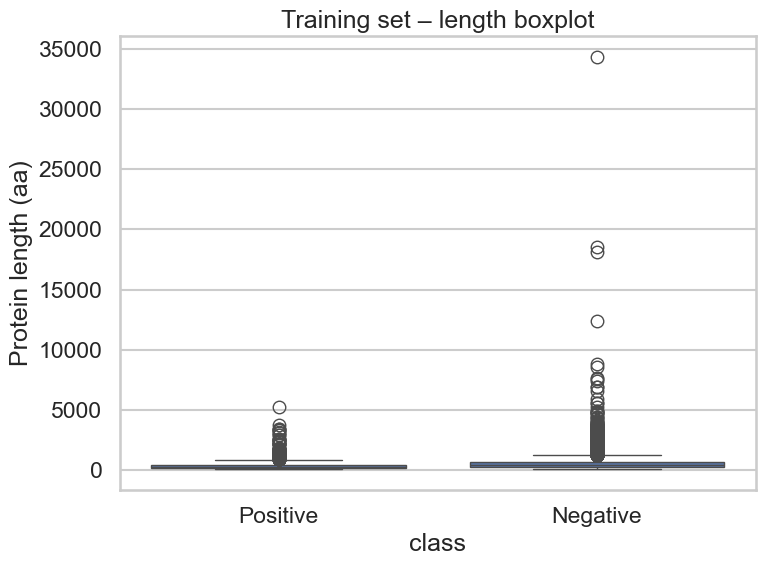

Saved: C:\Users\b1795\Desktop\Laboratory2_SP\figures\training_length_boxplot.png


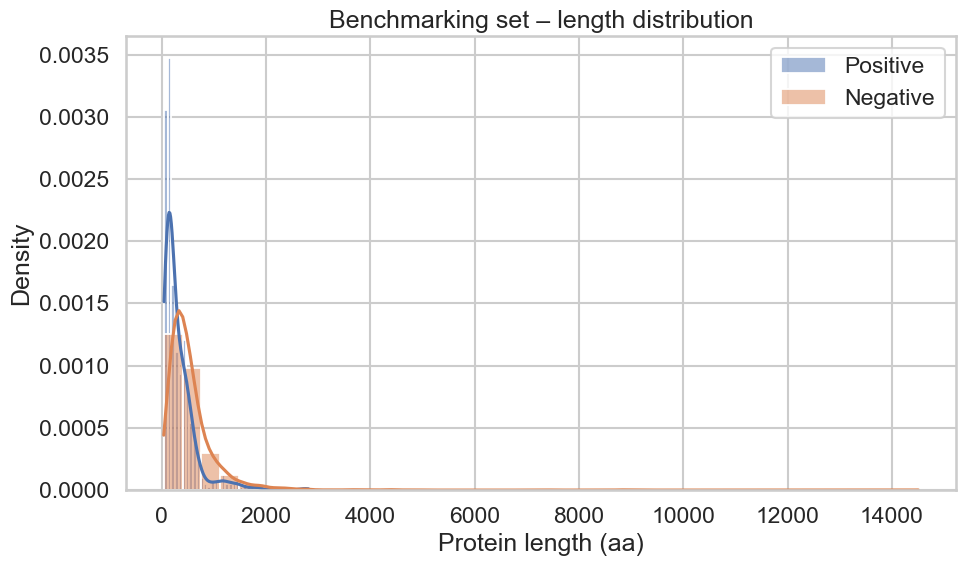

Saved: C:\Users\b1795\Desktop\Laboratory2_SP\figures\benchmark_length_hist_kde.png


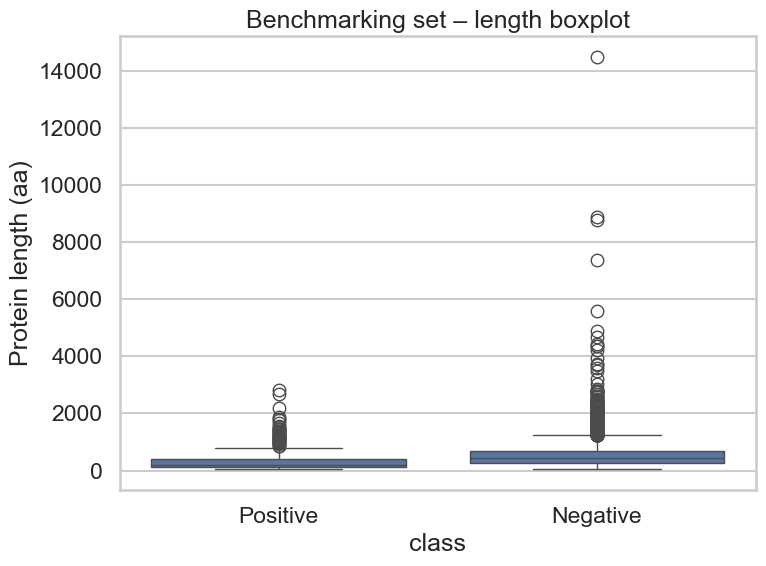

Saved: C:\Users\b1795\Desktop\Laboratory2_SP\figures\benchmark_length_boxplot.png


In [3]:
# First determine the length column name
len_col_pos = pick_column(df_train_pos, ["length", "seq_length", "protein_length"])
len_col_neg = pick_column(df_train_neg, ["length", "seq_length", "protein_length"])

print("Length column (pos):", len_col_pos)
print("Length column (neg):", len_col_neg)

def plot_length_distribution(df_pos, df_neg, len_col, title_prefix, out_prefix):
    """
    Plot length distributions: positive/negative overlay histogram with KDE and boxplot.
    """
    plt.figure(figsize=(10, 6))
    sns.histplot(df_pos[len_col], bins=40, stat="density", kde=True, label="Positive", alpha=0.5)
    sns.histplot(df_neg[len_col], bins=40, stat="density", kde=True, label="Negative", alpha=0.5)
    plt.xlabel("Protein length (aa)")
    plt.ylabel("Density")
    plt.title(f"{title_prefix} – length distribution")
    plt.legend()
    out_path = os.path.join(FIGURES_DIR, f"{out_prefix}_length_hist_kde.png")
    plt.tight_layout()
    plt.savefig(out_path, dpi=300)
    plt.show()
    print("Saved:", out_path)
    # boxplot
    plt.figure(figsize=(8, 6))
    stacked = pd.concat([
        pd.DataFrame({ "length": df_pos[len_col], "class": "Positive" }),
        pd.DataFrame({ "length": df_neg[len_col], "class": "Negative" }),
    ], ignore_index=True)
    sns.boxplot(data=stacked, x="class", y="length")
    plt.ylabel("Protein length (aa)")
    plt.title(f"{title_prefix} – length boxplot")
    out_path_box = os.path.join(FIGURES_DIR, f"{out_prefix}_length_boxplot.png")
    plt.tight_layout()
    plt.savefig(out_path_box, dpi=300)
    plt.show()
    print("Saved:", out_path_box)
# Training set
plot_length_distribution(
    df_train_pos, df_train_neg, len_col_pos, "Training set", "training"
)
# Benchmarking set
len_col_bench_pos = pick_column(df_bench_pos, [len_col_pos, "length", "seq_length"])
len_col_bench_neg = pick_column(df_bench_neg, [len_col_neg, "length", "seq_length"])
plot_length_distribution(
    df_bench_pos, df_bench_neg, len_col_bench_pos, "Benchmarking set", "benchmark"
)

## 4. Signal peptide length distributions (positive only)

In [4]:
print("df_train_pos columns:")
print(list(df_train_pos.columns))
print(df_train_pos.head(3))

print("\ndf_bench_pos columns:")
print(list(df_bench_pos.columns))
print(df_bench_pos.head(3))

df_train_pos columns:
['accession', 'organism', 'kingdom', 'length', 'sp_cleavage_site', 'set_label']
  accession                      organism  kingdom  length  sp_cleavage_site  \
0    P56611              Tityus bahiensis  Metazoa      84                20   
1    Q10ST8  Oryza sativa subsp. japonica   Plants      96                27   
2    Q8WPD0           Patiria pectinifera  Metazoa     168                18   

        set_label  
0  train_positive  
1  train_positive  
2  train_positive  

df_bench_pos columns:
['accession', 'organism', 'kingdom', 'length', 'sp_cleavage_site', 'set_label']
  accession                                           organism  kingdom  \
0    Q6QD51                                  Rattus norvegicus  Metazoa   
1    P21588                                  Rattus norvegicus  Metazoa   
2    B0XT72  Aspergillus fumigatus (strain CBS 144.89 / FGS...    Fungi   

   length  sp_cleavage_site       set_label  
0     949                27  bench_positive  
1

Training positive SP length stats:
 count    2348.000000
mean       22.554089
std         5.391614
min        14.000000
25%        19.000000
50%        22.000000
75%        25.000000
max        70.000000
Name: sp_cleavage_site, dtype: float64
Benchmark positive SP length stats:
 count    587.000000
mean      22.327087
std        4.758179
min       14.000000
25%       19.000000
50%       21.000000
75%       25.000000
max       40.000000
Name: sp_cleavage_site, dtype: float64


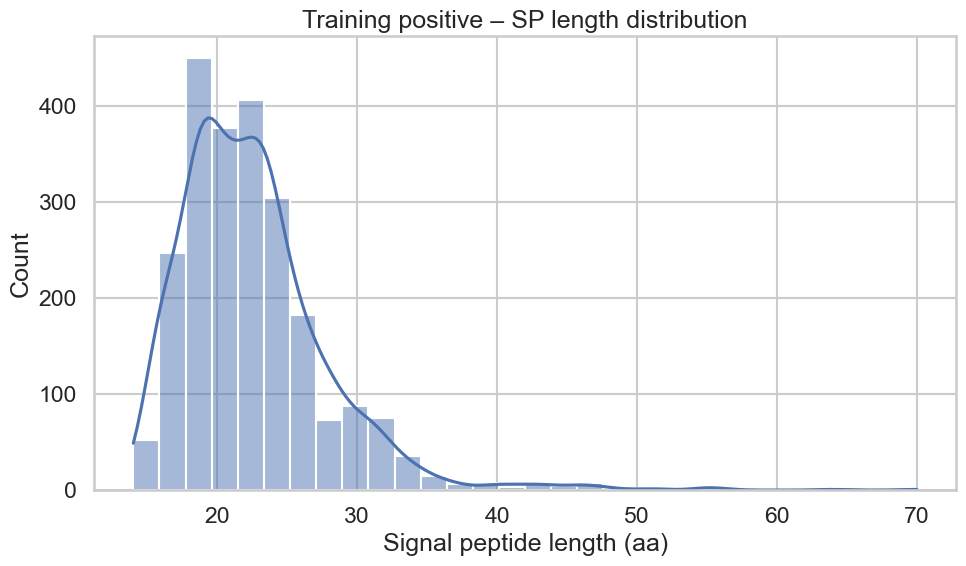

Saved: C:\Users\b1795\Desktop\Laboratory2_SP\figures\training_positive_sp_length_hist.png


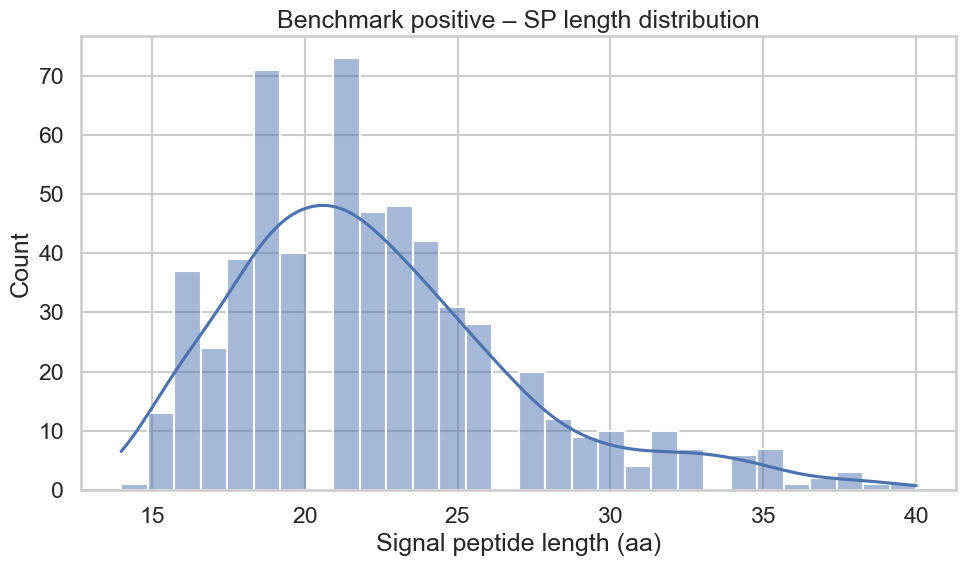

Saved: C:\Users\b1795\Desktop\Laboratory2_SP\figures\benchmark_positive_sp_length_hist.png


In [5]:
def compute_sp_length(df):
    """
    Return a column of signal peptide lengths:
    - Use an existing sp_length-like column if available
    - Otherwise compute it from the cleavage column (assuming SP spans from 1 to cleavage_end)
    """
    # 1) Use the precomputed column directly
    sp_len_col = pick_column(
        df,
        ["sp_length", "SP_length", "signal_peptide_length"],
        required=False
    )
    if sp_len_col is not None:
        return df[sp_len_col].astype(int)
    # 2) Attempt to compute using cleavage position
    cleav_col = pick_column(
        df,
        ["sp_cleavage_site", "cleavage_position", "cleavage_site", "sp_end", "signal_peptide_end"],
        required=False
    )
    if cleav_col is not None:
        # For a typical signal peptide: start = 1, end = cleavage position
        return df[cleav_col].astype(int)
    raise KeyError("Cannot determine SP length: no 'sp_length' or cleavage position columns found.")
sp_len_train = compute_sp_length(df_train_pos)
sp_len_bench = compute_sp_length(df_bench_pos)

print("Training positive SP length stats:\n", sp_len_train.describe())
print("Benchmark positive SP length stats:\n", sp_len_bench.describe())

def plot_sp_length(sp_len, title_prefix, out_prefix):
    plt.figure(figsize=(10, 6))
    sns.histplot(sp_len, bins=30, kde=True)
    plt.xlabel("Signal peptide length (aa)")
    plt.ylabel("Count")
    plt.title(f"{title_prefix} – SP length distribution")
    out_path = os.path.join(FIGURES_DIR, f"{out_prefix}_sp_length_hist.png")
    plt.tight_layout()
    plt.savefig(out_path, dpi=300)
    plt.show()
    print("Saved:", out_path)

plot_sp_length(sp_len_train, "Training positive", "training_positive")
plot_sp_length(sp_len_bench, "Benchmark positive", "benchmark_positive")

## 5. Amino-acid composition of SPs vs SwissProt
- Extract SP sequences from training positives
- Compute frequency (%) of each amino acid (20 standard)
- Compare with SwissProt background composition (from Expasy statistics)
- Display as grouped barplot

Loaded 2935 sequences from C:\Users\b1795\Desktop\Laboratory2_SP\data_raw\positive.fasta
Extracted 2348 SP sequences from training positives.
Example SP composition (few AAs): {'A': 0.1305612206359997, 'C': 0.02974167233174711, 'D': 0.008025530629201602, 'E': 0.014559256741445729, 'F': 0.04915401465367475}


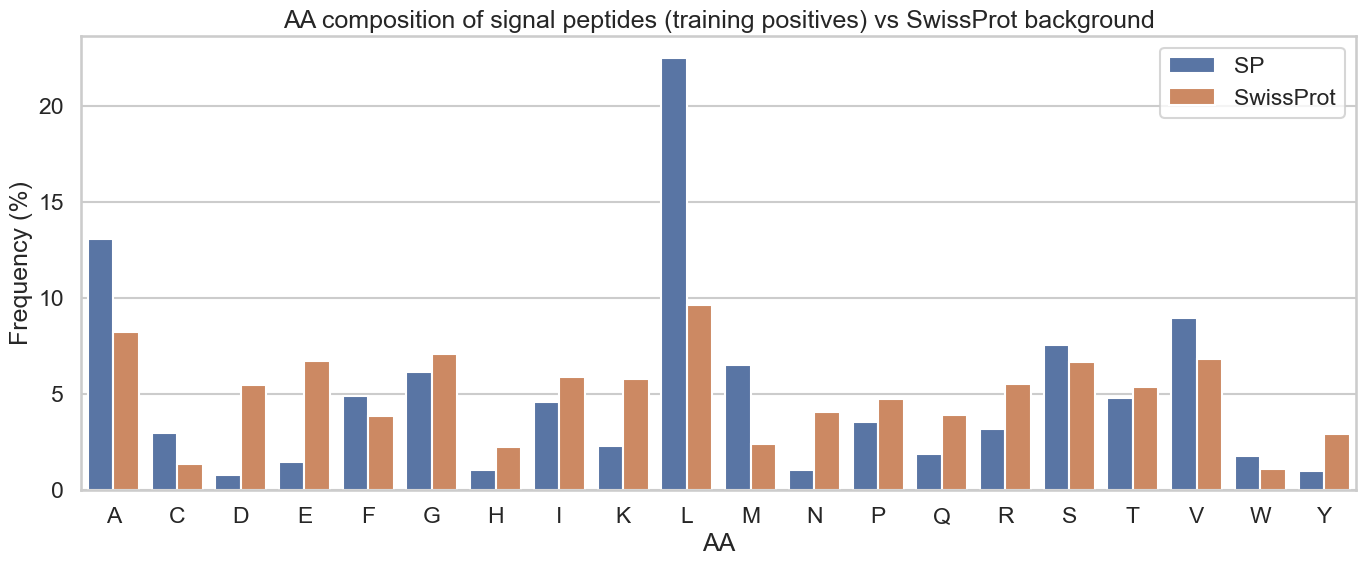

Saved: C:\Users\b1795\Desktop\Laboratory2_SP\figures\sp_vs_swissprot_aa_composition.png


In [6]:
AA_ORDER = list("ACDEFGHIKLMNPQRSTVWY")  # Fixed amino acid order
def load_fasta_dict(fasta_path):
    """读取 FASTA 文件并返回 {Accession: Sequence} 字典"""
    seqs = {}
    header = None
    seq = []
    if not os.path.exists(fasta_path):
        print(f"Warning: FASTA file not found: {fasta_path}")
        return {}
    with open(fasta_path, "r") as f:
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                if header:
                    seqs[header] = "".join(seq)
                header = line[1:].split()[0] # Extract accession
                seq = []
            else:
                seq.append(line)
        if header:
            seqs[header] = "".join(seq)
    print(f"Loaded {len(seqs)} sequences from {fasta_path}")
    return seqs

# Load raw FASTA (containing full amino acid sequences)
POS_RAW_FASTA = os.path.join(DATA_RAW_DIR, "positive.fasta")
seq_dict_pos = load_fasta_dict(POS_RAW_FASTA)


def extract_sp_sequences(df, seq_dict):
    """
    Extract signal peptide sequences from the FASTA dictionary based on cleavage positions.
    """
    # 1. Only accession and cleavage site columns are required
    acc_col = pick_column(df, ["accession", "Entry"], required=True)
    cleav_col = pick_column(
        df,
        ["sp_cleavage_site", "cleavage_position", "cleavage_site", "sp_end"],
        required=True
    )

    seqs = []
    for _, row in df.iterrows():
        acc = row[acc_col]
        # 2. Use accession to look up the sequence in the dictionary
        if acc in seq_dict:
            full_seq = str(seq_dict[acc])
            end = int(row[cleav_col]) # 1-based end position
            # 3. Extract signal peptide sequence
            sp_seq = full_seq[:end]   # Python slicing excludes the end index, which matches the 1-based conversion
            seqs.append(sp_seq)
            
    return seqs


def compute_aa_composition(seqs):
    """Given a list of amino acid sequences, return a frequency dictionary between 0 and 1."""
    counter = Counter()
    total = 0
    for s in seqs:
        for aa in s:
            if aa in AA_ORDER:
                counter[aa] += 1
                total += 1
    # Prevent division by zero
    comp = {aa: (counter[aa] / total if total > 0 else 0.0) for aa in AA_ORDER}
    return comp

# Extract SP sequences from training positives and compute amino acid composition
sp_seqs_train = extract_sp_sequences(df_train_pos, seq_dict_pos)
print(f"Extracted {len(sp_seqs_train)} SP sequences from training positives.")

sp_comp = compute_aa_composition(sp_seqs_train)
print("Example SP composition (few AAs):",
        {k: sp_comp[k] for k in list(sp_comp.keys())[:5]})

# SwissProt background composition (hard-coded from official statistics, unit: percent)
# Values are derived from the Swiss-Prot “6 AMINO ACID COMPOSITION”
SWISSPROT_PERCENT = {
    "A": 8.25, "R": 5.52, "N": 4.06, "D": 5.46, "C": 1.38,
    "Q": 3.93, "E": 6.71, "G": 7.07, "H": 2.27, "I": 5.90,
    "L": 9.64, "K": 5.79, "M": 2.41, "F": 3.86, "P": 4.74,
    "S": 6.65, "T": 5.36, "W": 1.10, "Y": 2.92, "V": 6.85,
}

def load_swissprot_background():
    """
    Return SwissProt amino acid composition (frequencies between 0 and 1)
    """
    bg = {aa: SWISSPROT_PERCENT.get(aa, 0) / 100.0 for aa in AA_ORDER}
    return bg
swissprot_comp = load_swissprot_background()

# Assemble a DataFrame and plot a bar chart
data = {
    "AA": AA_ORDER,
    "SP": [sp_comp[aa] * 100 for aa in AA_ORDER],           # Convert to percentage
    "SwissProt": [swissprot_comp[aa] * 100 for aa in AA_ORDER],
}
df_comp = pd.DataFrame(data)

df_comp_long = df_comp.melt(
    id_vars="AA",
    value_vars=["SP", "SwissProt"],
    var_name="Dataset",
    value_name="Frequency_percent",
)

# grouped barplot:
plt.figure(figsize=(14, 6))
sns.barplot(data=df_comp_long, x="AA", y="Frequency_percent", hue="Dataset")
plt.ylabel("Frequency (%)")
plt.title("AA composition of signal peptides (training positives) vs SwissProt background")
plt.legend(title="")
out_path = os.path.join(FIGURES_DIR, "sp_vs_swissprot_aa_composition.png")
plt.tight_layout()
plt.savefig(out_path, dpi=300)
plt.show()
print("Saved:", out_path)

## 6. Taxonomic classification (species level)
- Use organism/species column from positive training and benchmarking
- Display as barplots (top N species)  

Organism column (train pos): organism
Organism column (bench pos): organism


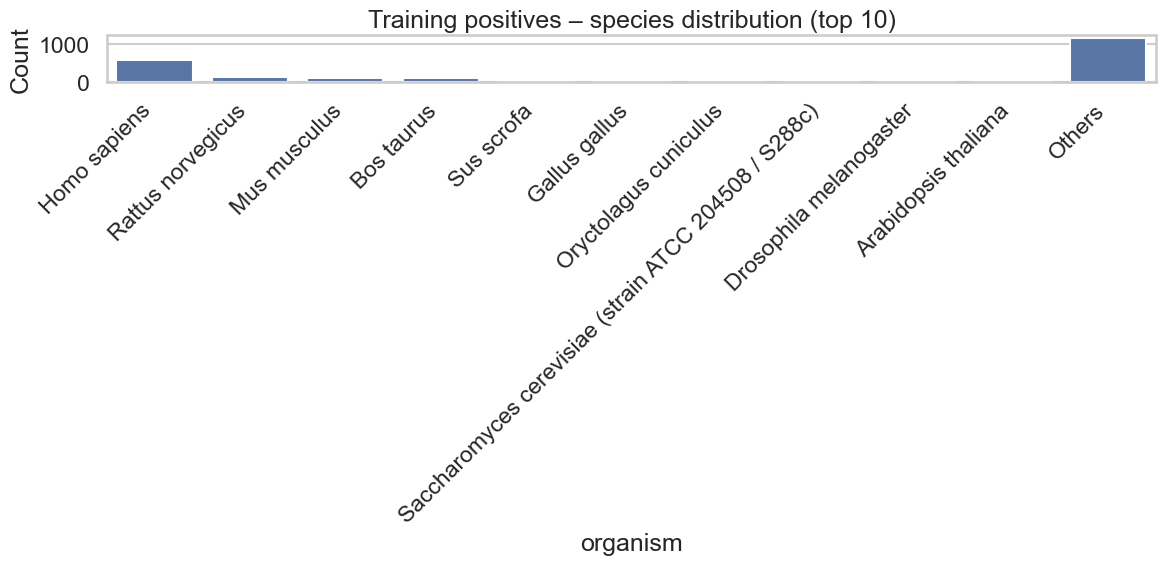

Saved: C:\Users\b1795\Desktop\Laboratory2_SP\figures\training_positive_species_barplot.png


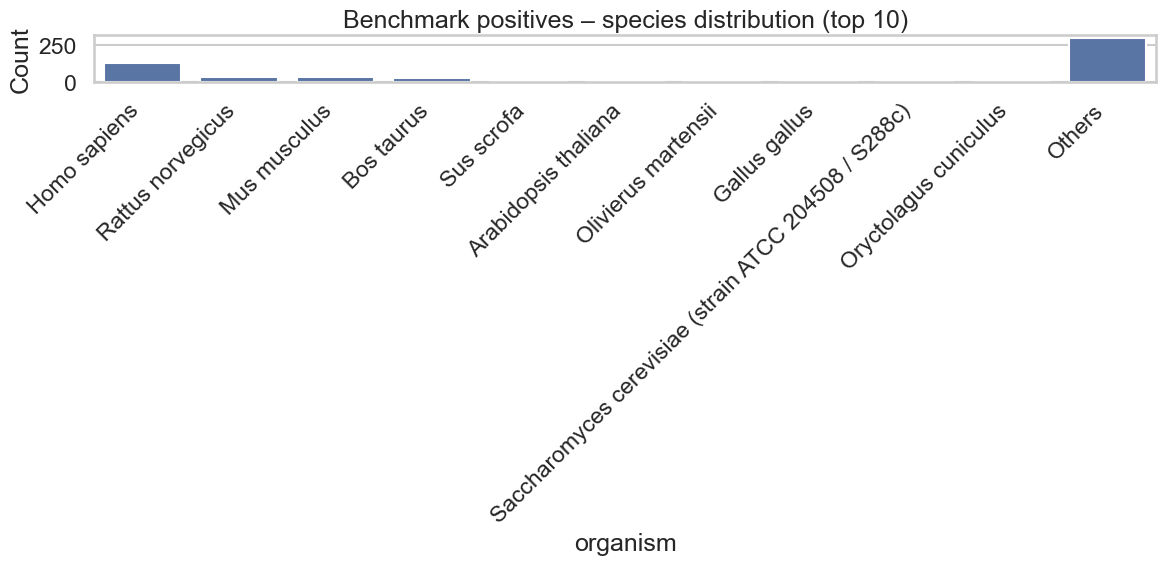

Saved: C:\Users\b1795\Desktop\Laboratory2_SP\figures\benchmark_positive_species_barplot.png


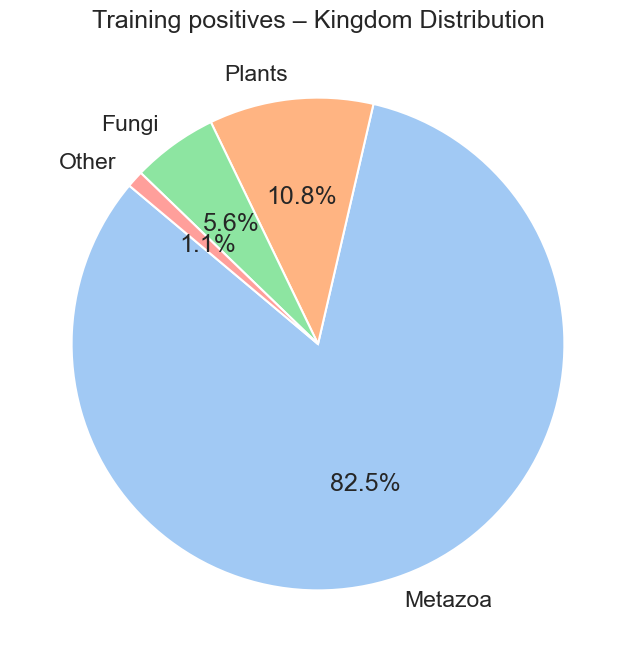

Saved: C:\Users\b1795\Desktop\Laboratory2_SP\figures\training_positive_kingdom_pie.png


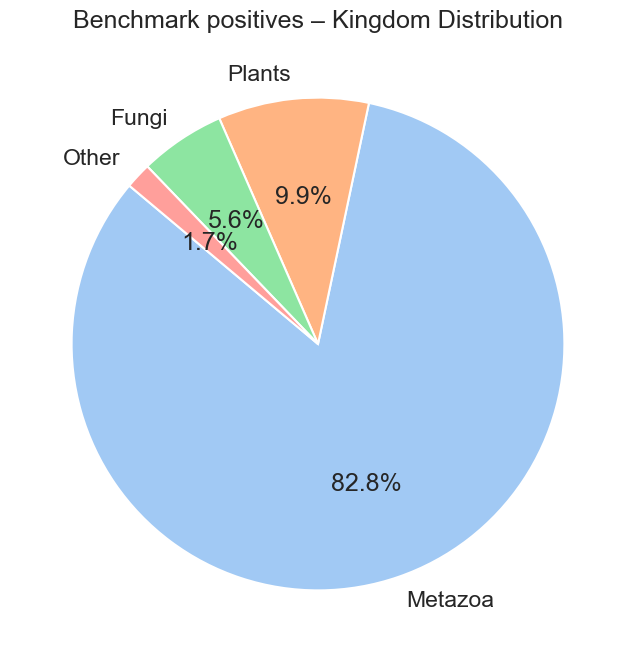

Saved: C:\Users\b1795\Desktop\Laboratory2_SP\figures\benchmark_positive_kingdom_pie.png


In [7]:
def get_species_column(df):
    """
    Identify the species / organism column
    """
    col = pick_column(df, ["organism", "Organism", "species", "Species"], required=True)
    return col

org_col_train_pos = get_species_column(df_train_pos)
org_col_bench_pos = get_species_column(df_bench_pos)
print("Organism column (train pos):", org_col_train_pos)
print("Organism column (bench pos):", org_col_bench_pos)

def plot_species_bar(df, org_col, title_prefix, out_prefix, top_n=10):
    counts = df[org_col].value_counts()
    top = counts.head(top_n)
    others = counts.iloc[top_n:].sum()
    plot_data = top.copy()
    if others > 0:
        plot_data["Others"] = others
    plt.figure(figsize=(12, 6))
    sns.barplot(x=plot_data.index, y=plot_data.values)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Count")
    plt.title(f"{title_prefix} – species distribution (top {top_n})")
    out_path = os.path.join(FIGURES_DIR, f"{out_prefix}_species_barplot.png")
    plt.tight_layout()
    plt.savefig(out_path, dpi=300)
    plt.show()
    print("Saved:", out_path)

plot_species_bar(df_train_pos, org_col_train_pos, "Training positives", "training_positive")
plot_species_bar(df_bench_pos, org_col_bench_pos, "Benchmark positives", "benchmark_positive")

# Kingdom Level Distribution
def plot_kingdom_pie(df, title_prefix, out_prefix):
    """Plot a pie chart of Kingdom distribution"""
    # The TSV file contains a column named 'kingdom'
    if "kingdom" not in df.columns:
        print(f"Skipping Kingdom plot for {title_prefix} (column not found)")
        return
    counts = df["kingdom"].value_counts()
    plt.figure(figsize=(8, 8))
    # Display percentages using autopct
    plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
    plt.title(f"{title_prefix} – Kingdom Distribution")
    
    out_path = os.path.join(FIGURES_DIR, f"{out_prefix}_kingdom_pie.png")
    plt.savefig(out_path, dpi=300)
    plt.show()
    print("Saved:", out_path)

# Generate plots
plot_kingdom_pie(df_train_pos, "Training positives", "training_positive")
plot_kingdom_pie(df_bench_pos, "Benchmark positives", "benchmark_positive")

## 7. Sequence logo of SP cleavage sites (-13, +2)
- Extract aligned windows around cleavage site from training positives
- Window: positions [-13, +2], total length = 15 aa
- Save as FASTA, use WebLogo (command-line) to generate PNG logo

Extracting cleavage site motifs...
Successfully extracted 2348 motifs.
File saved to: C:\Users\b1795\Desktop\Laboratory2_SP\data_processed\sp_cleavage_windows.fasta
Manually use the WebLogo online tool to generate a signal peptide cleavage site sequence logo (Sequence Logo of SP cleavage site)
Displaying Generated Sequence Logo


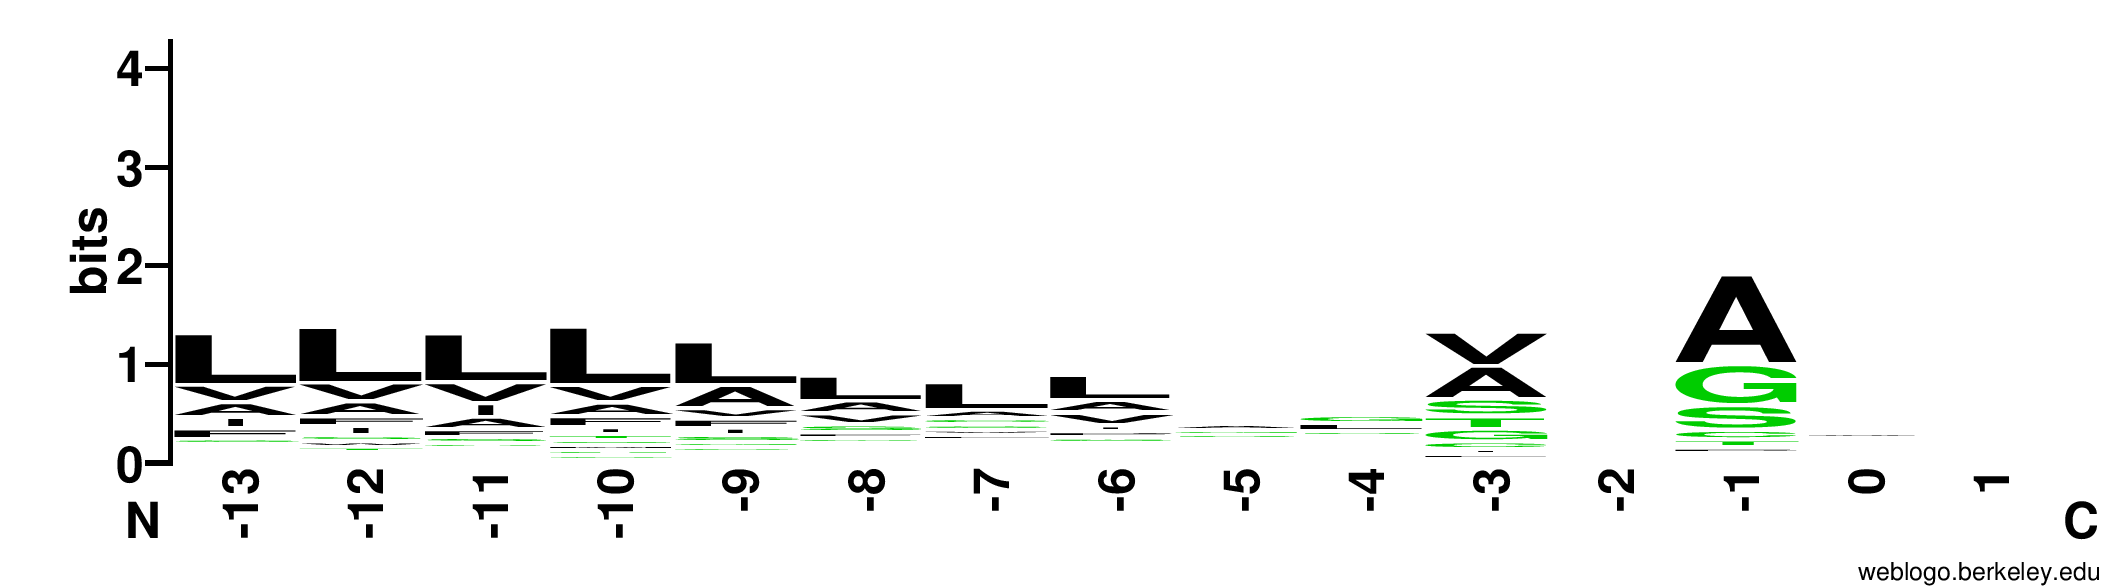

In [8]:
def extract_cleavage_windows(df, seq_dict, window_left=13, window_right=2):
    """
    Extract sequence windows around cleavage sites from the FASTA dictionary.
    Window range: [Cleavage - 13, Cleavage + 2]
    """
    cleav_col = pick_column(
        df,
        ["sp_cleavage_site", "cleavage_position", "cleavage_site", "sp_end"],
        required=True
    )
    acc_col = pick_column(df, ["accession", "Entry"], required=True)
    
    windows = []
    for _, row in df.iterrows():
        acc = row[acc_col]
        if acc not in seq_dict:
            continue
            
        full_seq = str(seq_dict[acc])
        site = int(row[cleav_col]) # 1-based cleavage position
        
        start_idx = site - window_left
        end_idx = site + window_right
        
        if start_idx < 0 or end_idx > len(full_seq):
            continue
            
        motif = full_seq[start_idx : end_idx]
        
        if len(motif) == (window_left + window_right):
            windows.append(motif)
            
    return windows

# Run extraction
print("Extracting cleavage site motifs...")
cleavage_windows = extract_cleavage_windows(df_train_pos, seq_dict_pos, window_left=13, window_right=2)

# Save FASTA file
CLEAVAGE_FASTA = os.path.join(DATA_PROCESSED_DIR, "sp_cleavage_windows.fasta")

with open(CLEAVAGE_FASTA, "w") as f:
    for i, seq in enumerate(cleavage_windows, start=1):
        f.write(f">seq_{i}\n{seq}\n")

print(f"Successfully extracted {len(cleavage_windows)} motifs.")
print(f"File saved to: {CLEAVAGE_FASTA}")
print("Manually use the WebLogo online tool to generate a signal peptide cleavage site sequence logo (Sequence Logo of SP cleavage site)")

# Display the Sequence Logo image here
# Image path
LOGO_PNG = os.path.join(FIGURES_DIR, "sp_cleavage_logo.png")

if os.path.exists(LOGO_PNG):
    print("Displaying Generated Sequence Logo")
    display(Image(filename=LOGO_PNG, width=800))  # width can be adjusted to control the display size
else:
    print(f"\n Warning: Image not found at {LOGO_PNG}")